In [ ]:
# Проект  - Анализ оттока и удержания клиентов в e-commerce
# Датасет: Olist (бразильский marketplace, есть на Kaggle, бесплатно, ~100K заказов, реальные данные о покупках, доставке, отзывах).
# Главный вопрос: Почему 97% клиентов не возвращаются после первой покупки и на какие факторы мы можем повлиять, чтобы это изменить?

# Структура анализа
# 1. DESCRIPTIVE (что происходит)
#    - Какой масштаб оттока и потери в деньгах?

# 2. DIAGNOSTIC (почему)
#    - Какие факторы, влияющие на возврат клиента?

# 3. PREDICTIVE (что будет)
#    - Кто в зоне риска?

# 4. PRESCRIPTIVE (что делать)
#    - Рекомендации с оценкой эффекта.

### **0. Загрузка и просмтр данных**

In [ ]:
import kagglehub
import os
import pandas as pd

# Download dataset latest version
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")

print("Path to dataset files:", path)

# посмотреть все файлы в папке
files = os.listdir(path)
for i in files:
  print(i)

# главные таблицы для анализа оттока
orders = pd.read_csv(f"{path}/olist_orders_dataset.csv")
customers = pd.read_csv(f"{path}/olist_customers_dataset.csv")
payments = pd.read_csv(f"{path}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{path}/olist_order_reviews_dataset.csv")
items = pd.read_csv(f"{path}/olist_order_items_dataset.csv")

print("\n=== 0.1. ПОСМОТР ПЕРВЫХ 5 СТРОК ===")
print("\n=== orders ===")
print(orders.head())
print("\n=== customers ===")
print(customers.head())
print("\n=== payments ===")
print(payments.head())
print("\n=== reviews ===")
print(reviews.head())
print("\n=== items ===")
print(items.head())

print("\n=== 0.2. РАЗМЕР ТАБЛИЦ(кол-во колонок и строк) ===")
print("\n=== orders ===")
print(orders.shape)
print("\n=== customers ===")
print(customers.shape)
print("\n=== payments ===")
print(payments.shape)
print("\n=== reviews ===")
print(reviews.shape)
print("\n=== items ===")
print(items.shape)

print("\n=== 0.3. ИНФОРМАЦИЯ О КОЛОНКАХ(типы колонок и кол-во нулевые значения) ===")
print("\n=== orders ===")
print(orders.info())
print("\n=== customers ===")
print(customers.info())
print("\n=== payments ===")
print(payments.info())
print("\n=== reviews ===")
print(reviews.info())
print("\n=== items ===")
print(items.info())

print("\n=== 0.4. ЧИСЛЕННАЯ СТАТИСТИКА(count, mean, std, min, 25%, 50%, 75%, max ===")
print("\n=== orders ===")
print(orders.describe())
print("\n=== customers ===")
print(customers.describe())
print("\n=== payments ===")
print(payments.describe())
print("\n=== reviews ===")
print(reviews.describe())
print("\n=== items ===")
print(items.describe())


100%|██████████| 42.6M/42.6M [00:03<00:00, 14.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/olistbr/brazilian-ecommerce/versions/2
olist_order_items_dataset.csv
olist_products_dataset.csv
olist_customers_dataset.csv
olist_orders_dataset.csv
olist_sellers_dataset.csv
olist_order_reviews_dataset.csv
olist_geolocation_dataset.csv
product_category_name_translation.csv
olist_order_payments_dataset.csv

=== 0.1. ПОСМОТР ПЕРВЫХ 5 СТРОК ===

=== orders ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered   

Вывод:
Olist — это связанные таблицы. Ключевая логика:

customers (клиенты)

    ↓ customer_id
orders (заказы)

    ↓ order_id
├── payments (сколько заплатили)

├── reviews (какой отзыв оставили)

└── items (какие товары купили)

у каждого клиента есть customer_unique_id — по нему видно повторные покупки.

### **1. Очистка данных**

In [ ]:
print("\n=== 1.1. Нулевые значения (NaN) ===")
print("\n=== orders ===")
print(orders.isnull().sum())
print("\n=== customers ===")
print(customers.isnull().sum())
print("\n=== payments ===")
print(payments.isnull().sum())
print("\n=== reviews ===")
print(reviews.isnull().sum())
print("\n=== items ===")
print(items.isnull().sum())


=== 1.1. Нулевые значения (NaN) ===

=== orders ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== customers ===
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

=== payments ===
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

=== reviews ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

=== items ===
order_id   

In [ ]:
# Null в Дате доставки — оставить + флаг
orders['is_delivered']=orders['order_delivered_customer_date'].notna()

#Null в Текстe отзывов — оставить + флаг
reviews['has_review_text']=reviews['review_comment_message'].notna()


Вывод:
Пропуски в датах доставки и тексте отзывов
НЕ заполнялись — они отражают реальные события:
- пустая дата доставки = заказ не доставлен
- пустой текст отзыва = клиент не оставил комментарий

Вместо заполнения создала бинарные флаги
(is_delivered, has_review_text) для анализа.

Заполнение (медиана/мода) применяется только к
второстепенным признакам, которые реально
существуют, но не записаны — и только когда
это не искажает предмет анализа.

In [ ]:
print("\n=== 1.2. Дубликаты ===")
print("\n=== orders ===")
print(orders.duplicated().sum())
print("\n=== customers ===")
print(customers.duplicated().sum())
print("\n=== payments ===")
print(payments.duplicated().sum())
print("\n=== reviews ===")
print(reviews.duplicated().sum())
print("\n=== items ===")
print(items.duplicated().sum())

# Удалить если есть
# orders = orders.drop_duplicates()
# orders.drop_dublicates(inplace=True)


=== 1.2. Дубликаты ===

=== orders ===
0

=== customers ===
0

=== payments ===
0

=== reviews ===
0

=== items ===
0


In [ ]:
print("\n=== 1.3. Неправильные типы ===")

print("\n=== Просмотр типа колонок ===")
print("\n=== orders ===")
print(orders.dtypes)
print("\n=== customers ===")
print(customers.dtypes)
print("\n=== payments ===")
print(payments.dtypes)
print("\n=== reviews ===")
print(reviews.dtypes)
print("\n=== items ===")
print(items.dtypes)



print("\n=== изменить типы дат ===")

print("\n=== orders ===")
date_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols_orders:
  orders[col]=pd.to_datetime(orders[col])
print(orders.dtypes)

print("\n=== reviews ===")
reviews['review_creation_date']=pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']=pd.to_datetime(reviews['review_answer_timestamp'])
print(reviews.dtypes)

print("\n=== items ===")
items['shipping_limit_date']=pd.to_datetime(items['shipping_limit_date'])
print(items.dtypes)


=== 1.3. Неправильные типы ===

=== Просмотр типа колонок ===

=== orders ===
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
is_delivered                       bool
dtype: object

=== customers ===
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

=== payments ===
order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

=== reviews ===
review_id                  object
order_id                   object
review_score                int64
review_comment_title       o

In [ ]:
print("\n=== 1.3. Аномалии и выбросы ===")

# Проверить статус заказов
print(orders['order_status'].value_counts())

print(',n')
# Странные значения в оплате? Отрицательные суммы? Нулевые? Гигантские?
print(payments['payment_value'].describe())


=== 1.3. Аномалии и выбросы ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64
,n
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


In [ ]:
#1. Нулевые платежи — сколько их и почему
zero_payments = payments[payments['payment_value']==0]
print("Нулевых платежей:", len(zero_payments))
print(zero_payments['payment_type'].value_counts())

Нулевых платежей: 9
payment_type
voucher        6
not_defined    3
Name: count, dtype: int64


voucher (6) → оставить, это реальные оплаты ваучером
not_defined (3) → можно удалить (мусор) или оставить
                  (всего 3 из 103886 — погоды не сделают)

Решение: не критично. 9 из 103886 = 0.009%


In [ ]:
#2. Экстремальные выбросы — где верхний хвост
print(payments['payment_value'].nlargest(10))

print("Платежей > 5000:", (payments['payment_value']>5000).sum())

52107    13664.08
34370     7274.88
41419     6929.31
49581     6922.21
85539     6726.66
62409     6081.54
43232     4950.34
70320     4809.44
6440      4764.34
67546     4681.78
Name: payment_value, dtype: float64
Платежей > 5000: 6


Дорогие выбросы (6 > 5000):
→ РЕАЛЬНЫЕ дорогие заказы
→ НЕ удалять! это настоящие покупки
→ они важны для анализа (VIP-клиенты)

In [ ]:
#3. Проверить цены и доставку в items
print(items['price'].describe())
print("Нулевых цен:", (items['price']==0).sum())
print("Нулевых цен:", (items['price']<0).sum())


print(items['freight_value'].describe())
print("Нулевая доставка:", (items['freight_value']==0).sum())
print("Нулевых цен:", (items['freight_value']<0).sum())

count    112650.000000
mean        120.653739
std         183.633928
min           0.850000
25%          39.900000
50%          74.990000
75%         134.900000
max        6735.000000
Name: price, dtype: float64
Нулевых цен: 0
Нулевых цен: 0
count    112650.000000
mean         19.990320
std          15.806405
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64
Нулевая доставка: 383
Нулевых цен: 0


freight = 0 может быть:

- Бесплатная доставка (промо, акция)
- Самовывоз
- Продавец включил доставку в цену товара

Это скорее всего НОРМА, не ошибка.
383 из 112650 = 0.3% — немного.

In [ ]:
#5 Проверить даты на логичность.Доставка раньше покупки? (логическая ошибка)
weird = orders[orders['order_delivered_customer_date']<orders['order_purchase_timestamp']]
print("Доставлено раньше покупки:", len(weird))

Доставлено раньше покупки: 0


In [ ]:
#6 review_score — в диапазоне 1-5?
print(reviews['review_score'].value_counts().sort_index())

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


In [ ]:
#7  payment_installments — логичность
print(payments['payment_installments'].describe())
print(payments['payment_installments'].value_counts().sort_index())

zero_install = payments[payments['payment_installments']==0]
res=zero_install.merge(orders, on='order_id')
print(res)

#замена
payments['payment_installments']=payments['payment_installments'].replace(0,1)
print(payments[payments['payment_installments']==0].sum())

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64
payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64
                           order_id  payment_sequential payment_type  \
0  744bade1fcf9ff3f31d860ace076d422                   2  credit_card   
1  1a57108394169c0b47d8f876acc9ba2d                   2  credit_card   

   payment_installments  payment_value                       customer_id  \
0                     0          58.69  5e5794daaa13f73e2f1cdb4114529843   
1                     0         129.94  48ebb06cf56dba9d009230cc751bb

Найдено 2 заказа с payment_installments = 0,
оплаченных картой на реальные суммы (58.69, 129.94)
и успешно доставленных.

Ноль платежей при реальной оплате картой —
ошибка записи. Исправлено на 1 (минимальный
логичный платёж), заказы сохранены.

In [ ]:
#7 Выбросы — метод IQR

Q1 = payments['payment_value'].quantile(0.25)
Q3 = payments['payment_value'].quantile(0.75)
IQR = Q3-Q1

#границы выбросов
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers = payments[    (payments['payment_value'] < lower) | (payments['payment_value'] > upper)]
print(f"Выбросов по IQR: {len(outliers)/len(payments)*100:.2f}%")
print(f"Верхняя граница: {upper:.2f}")

Выбросов по IQR: 7.68%
Верхняя граница: 344.41


Метод IQR пометил 7.68% платежей как выбросы
(граница 344.41). Однако это перекошенное
распределение (правый хвост дорогих заказов),
а не ошибки.

Значения 344–13664 — реальные крупные покупки,
не аномалии. Удаление исказило бы анализ и
потеряло ценных клиентов.

Решение: выбросы сохранены. Для метрик
используется median (устойчива к перекосу),
а не mean.

# 1. DESCRIPTIVE (что происходит)
#    - Какой масштаб оттока и потери в деньгах?

In [ ]:
# 1.1 сколько клиентов возвращаются ?

# соединяем заказы с клиентами
df = orders.merge(customers, on='customer_id')
print(len(df))

# только доставленные
df=df[df['order_status']=='delivered']
print(len(df))

# сколько покупок на человека
purchases = df.groupby('customer_unique_id').size()
print(purchases)
print(purchases.value_counts())
print(purchases.value_counts().sort_index())
print("\nДоля одноразовых:",(purchases==1).mean().round(4))

99441
96478
customer_unique_id
0000366f3b9a7992bf8c76cfdf3221e2    1
0000b849f77a49e4a4ce2b2a4ca5be3f    1
0000f46a3911fa3c0805444483337064    1
0000f6ccb0745a6a4b88665a16c9f078    1
0004aac84e0df4da2b147fca70cf8255    1
                                   ..
fffcf5a5ff07b0908bd4e2dbc735a684    1
fffea47cd6d3cc0a88bd621562a9d061    1
ffff371b4d645b6ecea244b27531430a    1
ffff5962728ec6157033ef9805bacc48    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Length: 93358, dtype: int64
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

Доля одноразовых: 0.97


**Вывод:**
- 97% клиентов покупают один раз;
- возвращаются 3%.

<Axes: xlabel='month'>

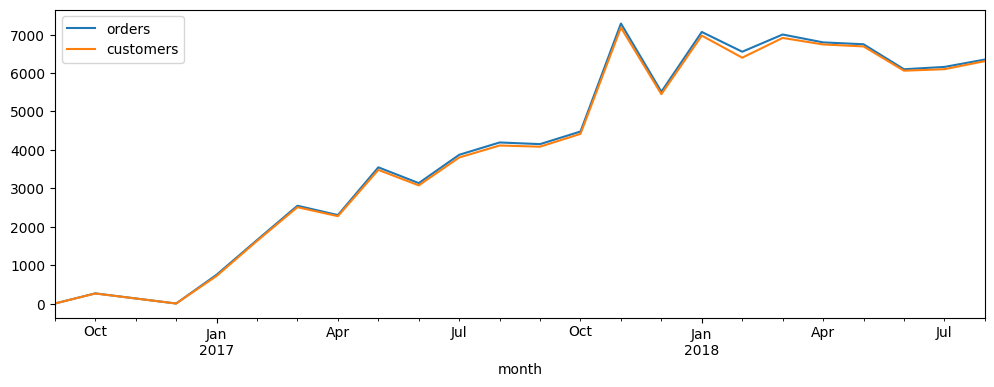

In [ ]:
# 1.2. Динамика кол-во заказов и покупателей во времени

df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly = df.groupby('month').agg(
    orders = ('order_id', 'count'),
    customers = ('customer_unique_id', 'nunique')
)

monthly.plot(figsize=(12,4))

**Выводы:**
- бизнес растет: с каждым месяцем все больше заказов
- повторных заказов почти нет, легкий рост в феврале 2018 года. рост только на новых клиентов.
- Пик был в ноябре 2017. Резкий скачок до ~7200, потом падение до ~5500 в декабре. На черную пятницу. Сезонный вплеск.
- с Дек 2016 по Ноя 2017 быстрый рост. дальше плато ~6000-7000. Бизнес вырос в первый год, потом уперся в потолок.
- с января 2018 линия плоская. без повторных покупок дальнейший рост возможен только за счет увеличения бюджета на привлечение.

Медианный чек: 105.29


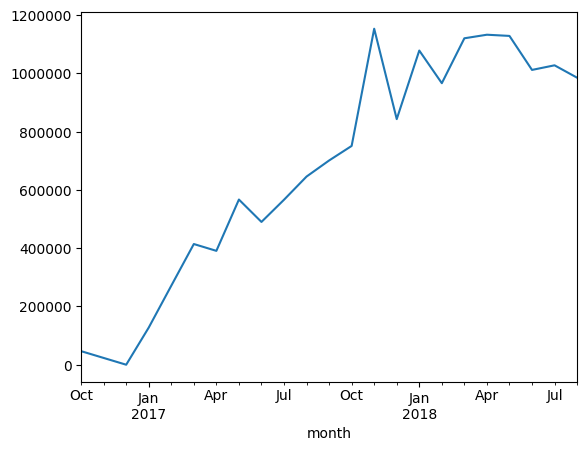

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1.3. Деньги
# средний чек (median, т.к. перекос)
order_value = payments.groupby('order_id')['payment_value'].sum()
print("Медианный чек:", order_value.median())

# выручка по месяцам

rev = df.merge(order_value.reset_index(), on='order_id')
ax = rev.groupby('month')['payment_value'].sum().plot()
ax.ticklabel_format(style='plain', axis='y')




<Axes: xlabel='month'>

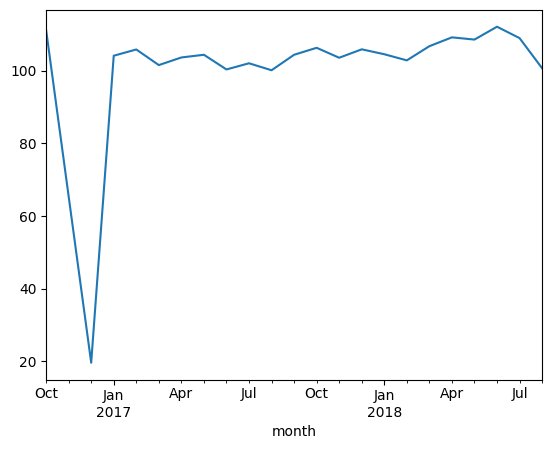

In [ ]:
# средний чек по месяцам
rev.groupby('month')['payment_value'].median().plot()

**Выводы:**
- Выручка выросла с нуля до ~1.1 млн, после вышла на плато и колеблется в диапазаоне 0.97–1.13 млн без выраженного тренда.
- рост выручки повторяет рост числа заказов - средний чек не увеличивается, повторных покупок нет. Выручка держится только на новых клиентах и уязвима к колебаниям притока.

Два пути роста: увеличивать средний чек или удерживать клиентов. Второе дешевле.

In [ ]:
# 1.4. Когортный анализ (сердце descriptive для retention)
# первая покупка каждого клиента = его когорта
first = df.groupby('customer_unique_id')['order_purchase_timestamp'].min()
df['cohort'] = df['customer_unique_id'].map(first).dt.to_period('M')

# сколько месяцев прошло с первой покупки
df['period'] = (df['month']-df['cohort']).apply(lambda x: x.n)

cohort_table = df.pivot_table(
    index='cohort', columns='period',
    values='customer_unique_id', aggfunc='nunique'
)
retention = cohort_table.divide(cohort_table[0], axis=0)
print((retention*100).round(1))

period      0      1    2    3    4    5    6    7    8    9    10   11   12  \
cohort                                                                         
2016-09  100.0    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2016-10  100.0    NaN  NaN  NaN  NaN  NaN  0.4  NaN  NaN  0.4  NaN  0.4  NaN   
2016-12  100.0  100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01  100.0    0.3  0.3  0.1  0.4  0.1  0.4  0.1  0.1  NaN  0.4  0.1  0.7   
2017-02  100.0    0.2  0.3  0.1  0.4  0.1  0.2  0.2  0.1  0.2  0.1  0.3  0.1   
2017-03  100.0    0.4  0.4  0.4  0.4  0.2  0.2  0.3  0.3  0.1  0.4  0.1  0.2   
2017-04  100.0    0.6  0.2  0.2  0.3  0.3  0.4  0.3  0.3  0.2  0.3  0.1  0.0   
2017-05  100.0    0.5  0.5  0.3  0.3  0.3  0.4  0.1  0.3  0.3  0.3  0.3  0.2   
2017-06  100.0    0.5  0.4  0.4  0.3  0.4  0.4  0.2  0.1  0.2  0.3  0.4  0.2   
2017-07  100.0    0.5  0.3  0.2  0.3  0.2  0.3  0.1  0.2  0.3  0.2  0.3  0.1   
2017-08  100.0    0.7  0.3  0.3  0.3  0.

In [ ]:
# 1.5. Базовые срезы для контекста
# топ категорий, регионов, способов оплаты
df['customer_state'].value_counts().head(10)
payments['payment_type'].value_counts()
reviews['review_score'].value_counts().sort_index()

# скорость доставки
df['delivery_days']=(df['order_delivered_customer_date']-df['order_purchase_timestamp']).dt.days
print("Медиана доставки:", df['delivery_days'].median(),"дней")

Медиана доставки: 10.0 дней


In [ ]:
# 1.6. Потери в деньгах от оттока (сколько недозарабатываем)

n_customers   = purchases.shape[0]        # уникальных клиентов (delivered)
one_time      = (purchases == 1).sum()    # купили ровно 1 раз
repeat        = (purchases > 1).sum()     # вернулись хотя бы раз
median_check  = order_value.median()      # медианный чек (устойчив к перекосу)
total_revenue = order_value.sum()         # вся выручка
actual_rate   = repeat / n_customers      # фактический retention ~3%

print(f"Клиентов всего:    {n_customers:,}")
print(f"Одноразовых:       {one_time:,}")
print(f"Медианный чек:     {median_check:.0f} R$")
print(f"Выручка всего:     {total_revenue:,.0f} R$")
print(f"Факт. retention:   {actual_rate*100:.1f}%\n")

# 1) Теоретический потолок: если бы КАЖДЫЙ одноразовый вернулся ещё раз
ceiling = one_time * median_check
print(f"Потолок упущенной выручки (все возвращаются 1 раз): "
      f"{ceiling:,.0f} R$ = {ceiling/total_revenue*100:.0f}% выручки\n")

# 2) Реалистичные сценарии по бенчмаркам (здоровый e-com держит 10–25%)
print("Упущенная выручка при выходе на бенчмарк retention:")
for bench in [0.10, 0.15, 0.20, 0.25]:
    lost_orders = (bench - actual_rate) * n_customers
    lost_rev    = lost_orders * median_check
    print(f"  {bench*100:.0f}% → +{lost_orders:,.0f} заказов, "
          f"{lost_rev:,.0f} R$ ({lost_rev/total_revenue*100:.0f}% выручки)")

Клиентов всего:    93,358
Одноразовых:       90,557
Медианный чек:     105 R$
Выручка всего:     16,008,872 R$
Факт. retention:   3.0%

Потолок упущенной выручки (все возвращаются 1 раз): 9,534,747 R$ = 60% выручки

Упущенная выручка при выходе на бенчмарк retention:
  10% → +6,535 заказов, 688,049 R$ (4% выручки)
  15% → +11,203 заказов, 1,179,532 R$ (7% выручки)
  20% → +15,871 заказов, 1,671,015 R$ (10% выручки)
  25% → +20,538 заказов, 2,162,499 R$ (14% выручки)


**Вывод:**
Денежный масштаб оттока. При фактическом retention 3% против отраслевой нормы 10–25%, упущенная выручка составляет от 0.69 млн R$ (+4% при выходе на 10%) до 2.16 млн R$ (+14% при 25%). Реалистичный ориентир — 15–20% retention, то есть ~1.2–1.7 млн R$, или 7–10% годовой выручки, недозарабатывается из-за того, что клиенты не возвращаются.

Теоретический потолок (если бы вернулись все одноразовые) — 9.5 млн R$, 60% выручки. Это верхняя граница масштаба, а не достижимая цель.

Вывод: отток — не косметическая проблема, а потеря порядка десятой части выручки ежегодно. Это оправдывает дальнейший анализ причин и мер.

**Выводы:**
- Месяц 1: возвращается 0.2–0.7% клиентов. Дальше:  0.1–0.4%. это катастрофа. Для сравнения, здоровый e-commerce: месяц 1 → 20–30% возврата
- Все 20+ корогот ведут себя +- одинаково, значит проблема системная, не сезонная. дело либо в продукте/модели.
- retention за 1.5 года никак не росла, компания в этот вопрос не угублялся.
- Важное замечание — аномалия в 2016-12. 2016-12: period 1 = 100.0. Это не успех, а артефакт: в декабре 2016 была всего 1 покупка. Один клиент вернулся — вот и 100%.
- Возвраты хаотичны (6-й, 11-й, 19-й месяц) — цикла
повторной покупки нет, что характерно для разовых
покупок.

# 2. DIAGNOSTIC (почему)
#    - Какие факторы, влияющие на возврат клиента?

In [ ]:
# признак: вернулся клиент или нет
customer_stats = df.groupby('customer_unique_id').agg(
    n_orders=('order_id', 'count'),
    first_order = ('order_purchase_timestamp', 'min')
)

customer_stats['returned']=customer_stats['n_orders']>1

# берём ПЕРВЫЙ заказ каждого клиента — по нему судим об опыте
first_orders = df.sort_values('order_purchase_timestamp').groupby('customer_unique_id').first().reset_index()

first_orders=first_orders.merge(
    customer_stats[['returned']], on ='customer_unique_id'
)

print(first_orders)

                     customer_unique_id                          order_id  \
0      0000366f3b9a7992bf8c76cfdf3221e2  e22acc9c116caa3f2b7121bbb380d08e   
1      0000b849f77a49e4a4ce2b2a4ca5be3f  3594e05a005ac4d06a72673270ef9ec9   
2      0000f46a3911fa3c0805444483337064  b33ec3b699337181488304f362a6b734   
3      0000f6ccb0745a6a4b88665a16c9f078  41272756ecddd9a9ed0180413cc22fb6   
4      0004aac84e0df4da2b147fca70cf8255  d957021f1127559cd947b62533f484f7   
...                                 ...                               ...   
93353  fffcf5a5ff07b0908bd4e2dbc735a684  725cf8e9c24e679a8a5a32cb92c9ce1e   
93354  fffea47cd6d3cc0a88bd621562a9d061  c71b9252fd7b3b263aaa4cb09319a323   
93355  ffff371b4d645b6ecea244b27531430a  fdc45e6c7555e6cb3cc0daca2557dbe1   
93356  ffff5962728ec6157033ef9805bacc48  94d3ee0bc2a0af9d4fa47a4d63616e8d   
93357  ffffd2657e2aad2907e67c3e9daecbeb  f79a35da168301ae56922475da21117b   

                            customer_id order_status order_purchase_timesta

In [ ]:
# Гипотеза 1 — скорость доставки
first_orders['delivery_days']=(
    first_orders['order_delivered_customer_date']-
    first_orders['order_purchase_timestamp']
    ).dt.days

print(first_orders.groupby('returned')['delivery_days'].median())

returned
False    10.0
True     10.0
Name: delivery_days, dtype: float64


**Вывод:** срок доставки в вернувшихся и нет - одинаковый. Влияния нет

In [ ]:
# Гипотеза 2 — опоздание против обещанного
first_orders['delay'] = (
    first_orders['order_delivered_customer_date']-
    first_orders['order_estimated_delivery_date']
).dt.days

first_orders['is_late']=first_orders['delay']>0

print(first_orders.groupby('is_late')['returned'].mean())

# размер групп
print(first_orders.groupby('is_late').agg(
    total=('returned', 'size'),
    returned=('returned', 'sum'),
    rate=('returned', 'mean')
))

is_late
False    0.030344
True     0.025330
Name: returned, dtype: float64
         total  returned      rate
is_late                           
False    87002      2640  0.030344
True      6356       161  0.025330


Вовремя:  3.03% вернулись
Опоздали: 2.53% вернулись

Разница: 3.03 - 2.53 = 0.5 п.п. (абсолютная)

Относительная: 0.5 / 3.03 = 0.165 = 16.5%

Опоздали:     6 356
Вовремя:     87 002
Всего:       93 358

6 356 / 93 358 = 0.068 = 6.8%

In [ ]:
from scipy.stats import chi2_contingency

table = pd.crosstab(first_orders['is_late'], first_orders['returned'])
chi2, p, dof, exp = chi2_contingency(table)
print(f"p-value: {p:.4f}")

p-value: 0.0262



p-value = 0.026 — разница статистически значима.
Опоздавшие возвращаются на 16.5% реже.

**Но практический эффект минимален.** Опоздания
затрагивают лишь 6.8% заказов. Полное устранение
опозданий подняло бы общий retention с 3.00% до
3.03% — на 0.03 п.п.

**Вывод:** статистическая значимость не равна
бизнес-значимости. Улучшение доставки не решит
проблему оттока — причина лежит глубже.

In [ ]:
# Гипотеза 3 — оценка заказа
fo = first_orders.merge(reviews[['order_id', 'review_score']], on='order_id')
print(fo.groupby('review_score')['returned'].mean()*100)

review_score
1    3.007024
2    3.093146
3    3.185127
4    2.975350
5    3.336062
Name: returned, dtype: float64


In [ ]:
# проверить стат значимость

table=pd.crosstab(fo['review_score'], fo['returned'])
chi, p, dof, exp = chi2_contingency(table)
print(p)

0.11542833612647


**Вывод:** p-value = 0.115 → связь статистически незначима.

Оценка заказа не влияет на вероятность возврата.
Даже клиенты с оценкой 5 возвращаются лишь в 3.3%
случаев — довольство не конвертируется в
повторную покупку.

In [ ]:
# Гипотеза 4 — стоимость доставки
freight = items.groupby('order_id')['freight_value'].sum()
fo = fo.merge(freight.reset_index(), on='order_id')
print(fo.groupby('returned')['freight_value'].median())


returned
False    17.19
True     16.68
Name: freight_value, dtype: float64


In [ ]:
diff=(17.19-16.68)/16.68*100
print(diff)

# проверить стат значимость
from scipy.stats import mannwhitneyu

a = fo[fo['returned']==False]['freight_value'].dropna()
b = fo[fo['returned']==True]['freight_value'].dropna()

stat, p = mannwhitneyu(a, b)
print(f"p-value: {p:.4f}")

3.057553956834542
p-value: 0.0330


**Вывод:**
Гипотеза 4 (стоимость доставки влияет на возврат): статистически значимая
разница обнаружена (p=0.033), однако практическая величина эффекта
незначительна (~3%), и возвращённые заказы имели немного меньшую стоимость доставки.
Стоимость доставки как самостоятельный драйвер возвратов не подтверждается.
Стратегия снижения этого фактора для уменьшения возвратов будет неэффективной.

In [ ]:
# Гипотеза 5 — сумма первого заказа

order_val = payments.groupby('order_id')['payment_value'].sum()
fo = fo.merge(order_val.reset_index(), on='order_id')
print(fo.groupby('returned')['payment_value'].median())

returned
False    105.37
True     100.15
Name: payment_value, dtype: float64


In [ ]:
from scipy.stats import mannwhitneyu

a = fo[fo['returned']==False]['payment_value'].dropna()
b = fo[fo['returned']==True]['payment_value'].dropna()

stat, p = mannwhitneyu(a, b)
print(f"Не вернулись: {a.median():.2f}")
print(f"Вернулись:    {b.median():.2f}")
print(f"p-value: {p:.4f}")

Не вернулись: 105.37
Вернулись:    100.15
p-value: 0.0001


**Вывод:**
p=0.0001 — статистически очень значимо,
и разница медиан содержательна: у клиентов, которые вернулись за повторной
покупкой (returned=True), медиана суммы первого платежа ~100.15,
что ниже, чем у клиентов, которые не вернулись (returned=False).

Инсайт: клиенты с более дешёвой первой покупкой возвращаются чаще,
чем клиенты с дорогой первой покупкой.

Бизнес-вывод: недорогая первая покупка работает как "точка входа" —
низкий чек снижает барьер для пробной покупки и повышает шанс повторного
визита. Дорогая первая покупка, наоборот, может быть разовой
("одноразовый" крупный заказ), после которой клиент не возвращается.

In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu

a = fo[fo['returned']==False]['payment_value'].dropna()
b = fo[fo['returned']==True]['payment_value'].dropna()

U, p = mannwhitneyu(a, b, alternative='two-sided')

n1, n2 = len(a), len(b)
N = n1 + n2

# U -> Z (нормальная аппроксимация, корректна при больших N)
mean_U = n1 * n2 / 2
std_U  = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
Z = (U - mean_U) / std_U

r = abs(Z) / np.sqrt(N)

print(f"p-value: {p:.6f}")
print(f"Z: {Z:.3f}")
print(f"r: {r:.4f}")

p-value: 0.000090
Z: 3.916
r: 0.0128


Effect size. p = 0.0001 подтверждает, что разница не случайна, но размер эффекта r ≈ 0.0128 — на порядок ниже порога «слабый эффект» (Шкала: маленький эффект — 0.1, средний — 0.3, большой — 0.5.). Значимость обеспечена объёмом выборки (~90 тыс.), а не силой связи.

Практическая значимость. Разница медиан первого чека — 5.22 R$ (5% от чека ~105 R
)
.
Дляценовойсегментацииэтонесущественно
;
ориентирзначимости—разрыв
20
–
30
𝑅
).Дляценовойсегментацииэтонесущественно;ориентирзначимости—разрыв 20–30R (20–30% чека).

Вывод: сумма первого заказа статистически связана с возвратом, но эффект настолько мал, что отдельная мера «снижать чек ради удержания» не окупится. Инсайт «дешёвая первая покупка = точка входа» остаётся как гипотеза для A/B-теста, но не как самостоятельный драйвер

In [ ]:
# Гипотеза 6 — категория товара
products = pd.read_csv(f"{path}/olist_products_dataset.csv")

fo_cat = (fo
    .merge(items[['order_id','product_id']], on='order_id')
    .merge(products[['product_id','product_category_name']], on='product_id'))

cat = fo_cat.groupby('product_category_name').agg(
    total=('returned','size'),
    rate=('returned','mean')
).query('total > 300').sort_values('rate', ascending=False)



In [ ]:
cat['rate_pct'] = cat['rate']*100
print("ТОП по возврату:\n", cat.head(10))
print("\nХУДШИЕ:\n", cat.tail(10))

ТОП по возврату:
                              total      rate   rate_pct
product_category_name                                  
eletrodomesticos               700  0.105714  10.571429
fashion_bolsas_e_acessorios   1841  0.061380   6.137968
moveis_decoracao              7737  0.055577   5.557710
cama_mesa_banho              10354  0.053892   5.389222
moveis_sala                    467  0.051392   5.139186
bebidas                        332  0.045181   4.518072
casa_conforto                  416  0.043269   4.326923
esporte_lazer                 8082  0.041326   4.132640
informatica_acessorios        7353  0.036312   3.631171
casa_construcao                571  0.033275   3.327496

ХУДШИЕ:
                        total      rate  rate_pct
product_category_name                           
bebes                   2888  0.023892  2.389197
papelaria               2402  0.023730  2.373022
relogios_presentes      5643  0.023569  2.356902
automotivo              4015  0.022914  2.291407
malas_

In [ ]:
from scipy.stats import chi2_contingency

top_cats = cat.index.tolist()
subset = fo_cat[fo_cat['product_category_name'].isin(top_cats)]
table = pd.crosstab(subset['product_category_name'], subset['returned'])
chi2, p, dof, exp = chi2_contingency(table)
print(f"p-value: {p:.6f}")

p-value: 0.000000


## Выводы диагностики

**Отток не объясняется качеством сервиса.**
Пять факторов (скорость и опоздание доставки,
оценка, стоимость доставки, сумма чека) не дают
практически значимого эффекта — даже клиенты
с идеальным опытом возвращаются в 3.3% случаев.

**Единственный работающий фактор — категория
товара**: разброс retention в 7 раз (1.5%→10.6%).
При этом решает не цена (бытовая техника 10.6%
vs электроника 1.5% — обе дорогие), а наличие
естественного повода вернуться.

Категории обустройства дома и стиля показывают
retention в 3 раза выше среднего, разовые
технические покупки — в 2 раза ниже.

**Корневая причина оттока — продуктовая модель,
а не операционное качество.**

# 3. PREDICTIVE (что будет)
#    - Кто в зоне риска?
предсказать, вернётся ли клиент, по данным его первого заказа.

In [ ]:
# Шаг 1 — собрать признаки
# базовая таблица: один клиент = одна строка
model_df = fo_cat.groupby('customer_unique_id').first().reset_index()

# признаки из первого заказа
features = model_df[[
    'delivery_days',
    'delay',
    'review_score',
    'freight_value',
    'payment_value',
    'product_category_name',
    'customer_state'
]].copy()

target = model_df['returned'].astype(int)

print(features.shape, target.mean())

(92741, 7) 0.02996517182260273


In [ ]:
# Шаг 2 — подготовка данных

# пропуски
# 1. Сначала честный признак
features['not_delivered'] = features['delivery_days'].isna().astype(int)

features.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92741 entries, 0 to 92740
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   delivery_days          92733 non-null  float64
 1   delay                  92733 non-null  float64
 2   review_score           92741 non-null  int64  
 3   freight_value          92741 non-null  float64
 4   payment_value          92741 non-null  float64
 5   product_category_name  91457 non-null  object 
 6   customer_state         92741 non-null  object 
 7   not_delivered          92741 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 5.7+ MB


In [ ]:

features = features.fillna({
    'delivery_days': features['delivery_days'].median(),
    'delay': features['delay'].median()
})

In [ ]:
# категории → числа (one-hot для топ-категорий)
top_cats = features['product_category_name'].value_counts().head(15).index
features['category'] = features['product_category_name'].where(
    features['product_category_name'].isin(top_cats), 'other'
)
print(features['category'] )

0           cama_mesa_banho
1              beleza_saude
2                     other
3                 telefonia
4                 telefonia
                ...        
92736          beleza_saude
92737                 bebes
92738            automotivo
92739    relogios_presentes
92740            perfumaria
Name: category, Length: 92741, dtype: object


In [ ]:
print(target)

0        0
1        0
2        0
3        0
4        0
        ..
92736    0
92737    0
92738    0
92739    0
92740    0
Name: returned, Length: 92741, dtype: int64


In [ ]:
# Модель понимает только числа → превращаем текстовые категории в колонки 0/1

X = pd.get_dummies(
    features.drop(columns=['product_category_name', 'customer_state']),  # убираем текстовые колонки
    columns=['category'],   # one-hot encoding: одна категория → своя колонка с 0/1
    drop_first=True         # убираем одну колонку — она вычисляется из остальных
)

y = target   # y — стандартное обозначение целевой переменной в sklearn

In [ ]:
# Шаг 3 — обучаем модель
from sklearn.model_selection import train_test_split      # разделение данных
from sklearn.linear_model import LogisticRegression       # сама модель
from sklearn.metrics import roc_auc_score, classification_report   # метрики качества

# Делим данные: 70% на обучение, 30% на проверку
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,      # доля тестовой выборки
    random_state=42,    # фиксирует перемешивание — результат воспроизводится
    stratify=y          # сохраняет долю вернувшихся (3%) в обеих частях
)

model = LogisticRegression(
    max_iter=1000,             # сколько итераций на подбор коэффициентов
    class_weight='balanced'    # компенсирует дисбаланс 97%/3%, иначе модель всех запишет в "уйдёт"
)
model.fit(X_train, y_train)   # обучение: модель подбирает веса по 70% данных

# predict_proba даёт две вероятности, [:, 1] берёт вероятность возврата
y_pred_proba = model.predict_proba(X_test)[:, 1]

# ROC-AUC: 0.5 = случайность, 0.7+ = рабочая модель
print("ROC-AUC:", round(roc_auc_score(y_test, y_pred_proba), 3))

ROC-AUC: 0.575


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Шаг 4 — смотрим на что модель опирается при прогнозе

importance = pd.DataFrame({
    'feature': X.columns,      # названия признаков
    'coef': model.coef_[0]     # веса модели, [0] — единственная строка для бинарной задачи
    # порядок коэффициентов совпадает с порядком колонок в X
}).sort_values('coef', key=abs, ascending=False)   # key=abs — сортируем по силе, а не по знаку

print(importance.head(10))   # знак = направление влияния, модуль = сила

                           feature      coef
9         category_cama_mesa_banho  0.771070
15       category_moveis_decoracao  0.711684
12          category_esporte_lazer  0.575436
13     category_ferramentas_jardim  0.412560
16                  category_other  0.301783
11            category_eletronicos -0.274320
20  category_utilidades_domesticas  0.240898
19              category_telefonia  0.231986
7            category_beleza_saude  0.215437
6                   category_bebes  0.167241


In [ ]:
# 3.1. rule-based scoring по трём операционным факторам (оценка, опоздание, чек)
# Берём всех первых покупателей
risk = first_orders.copy()

# Добавляем факторы риска
risk = risk.merge(reviews[['order_id', 'review_score']], on='order_id', how='left')

order_val = payments.groupby('order_id')['payment_value'].sum()
risk = risk.merge(order_val.reset_index(), on='order_id', how='left')

# Признаки риска
risk['low_score']    = risk['review_score'] <= 3          # недовольный клиент
risk['is_late']      = risk['delay'] > 0                  # опоздавшая доставка
risk['high_payment'] = risk['payment_value'] > 200        # высокий чек

# Балл риска (0–3)
risk['risk_score'] = (
    risk['low_score'].astype(int) +
    risk['is_late'].astype(int) +
    risk['high_payment'].astype(int)
)

# Сегменты
risk['segment'] = pd.cut(
    risk['risk_score'],
    bins=[-1, 0, 1, 3],
    labels=['Низкий риск', 'Средний риск', 'Высокий риск']
)

print(risk.groupby('segment', observed=True)['returned'].mean() * 100)
print(risk['segment'].value_counts())

segment
Төмен тәуекел     3.297742
Орташа тәуекел    3.143121
Жоғары тәуекел    2.873427
Name: returned, dtype: float64
segment
Төмен тәуекел     58161
Орташа тәуекел    27075
Жоғары тәуекел     8422
Name: count, dtype: int64


/tmp/ipykernel_1356/2393389596.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(risk.groupby('segment')['returned'].mean() * 100)


rule-based скоринг на операционных факторах (метод без ML, как в задании) дал слабое разделение — все сегменты в районе 3% retention (разброс 0.43 п.п.). Это не недостаток метода, а третье независимое подтверждение диагностики: сначала p-value и effect size показали, что эти факторы не работают по отдельности; затем логрегрессия (ROC-AUC 0.575) — что они не работают вместе; теперь rule-based скоринг — что они не работают и в виде правил. Единственный фактор, дающий реальное разделение (2 п.п.), — категория товара. Вывод устойчив: причина оттока структурная.

In [ ]:
# 3.2. Сегментация риска оттока (кто в зоне риска)
# Индивидуальный скоринг не работает (ROC-AUC 0.575),
# но на уровне сегментов сигнал есть: retention по категориям различается в разы.
# → строим не модель, а правило-сегментацию по категории первого заказа.

# 1) retention каждой надёжной категории (>=500 клиентов, иначе % случаен)
cat_ret = (fo_cat.groupby('product_category_name')
           .agg(clients=('customer_unique_id', 'nunique'),
                retention=('returned', 'mean'))
           .query('clients >= 500'))

# 2) три тира риска по терцилям retention
cat_ret['risk_tier'] = pd.qcut(
    cat_ret['retention'], 3,
    labels=['Высокий риск', 'Средний', 'Низкий риск']
)
risk_map = cat_ret['risk_tier'].to_dict()

# 3) метка риска каждому клиенту по категории его первого заказа
model_df['risk_tier'] = (model_df['product_category_name']
                         .map(risk_map).fillna('Средний'))

# 4) валидация: сегментация реально разделяет retention?
seg = model_df.groupby('risk_tier').agg(
    clients=('customer_unique_id', 'count'),
    actual_retention=('returned', 'mean')
)
seg['actual_retention'] = (seg['actual_retention'] * 100).round(2)
print(seg)

              clients  actual_retention
risk_tier                              
Высокий риск    20188              1.97
Низкий риск     35245              3.99
Средний         37308              2.62


**Вывод: **
Сегментация риска. Клиенты разделены на три тира по retention категории первого заказа. Сегментация валидна — фактический retention монотонно растёт от высокого риска (1.97%) к низкому (3.99%), разрыв 2x. Это отвечает на вопрос «кто в зоне риска»: клиенты из низко-retention категорий возвращаются вдвое реже.

Однако различие — относительное, не абсолютное: даже сегмент низкого риска возвращается лишь в 4% случаев (норма e-com 20–30%). Сегментация ранжирует риск, но не выделяет группу с реально высоким удержанием.

Вывод: индивидуальный churn-скоринг нецелесообразен (ROC-AUC 0.575) — внутри сегмента «уйдёт/останется» неотличимы. Работать нужно на уровне сегментов: удерживающие механики направлять на клиентов высокого и среднего риска (57 496 человек, 61% базы). Но потолок такого таргетинга ограничен — причина оттока структурная, а не поведенческая.

## Predictive Выводы:

### Модель
Логистическая регрессия на признаках первого заказа
(скорость доставки, опоздание, оценка, стоимость
доставки, сумма чека, категория товара).

**ROC-AUC = 0.575** — модель едва превосходит
случайное угадывание (0.5).

### Что оказалось важным
| Признак | Коэффициент |
|---|---|
| Домашний текстиль | +0.79 |
| Мебель и декор | +0.74 |
| Спорт и отдых | +0.59 |
| Сад и инструменты | +0.43 |
| Прочее | +0.32 |
| Электроника | −0.25 |

Все значимые признаки модели — категории товара.
Операционные метрики (доставка, оценка, чек) не
вошли в топ, что независимо подтверждает выводы
диагностики.

### Выводы

**1. Индивидуальный прогноз оттока невозможен.**
Низкий ROC-AUC означает, что по данным первого
заказа нельзя надёжно определить, вернётся ли
конкретный клиент.

**2. Это не недостаток модели, а свойство данных.**
Диагностика показала: сильных предикторов возврата
не существует. Модель не может извлечь сигнал,
которого нет.

**3. Единственный работающий фактор — категория.**
Модель самостоятельно пришла к тому же выводу,
что и статистический анализ.

### Практическая рекомендация
Строить churn-скоринг(присвоение каждому клиенту балла вероятности того, что он уйдёт) для Olist нецелесообразно —
он не даст бизнесу полезных предсказаний.

Ресурсы следует направить не на выявление
«клиентов группы риска», а на изменение продуктовой
модели: развитие категорий с высоким retention
и создание поводов для повторной покупки.


# 4. PRESCRIPTIVE (что делать)
#    - Рекомендации с оценкой эффекта.

In [ ]:
# Считаем эффект от работы с приоритетными категориями

# Три категории с наибольшим потенциалом удержания
high_ret = ['cama_mesa_banho','moveis_decoracao','esporte_lazer']

# .isin() фильтрует эти категории, .nunique() считает уникальных клиентов (людей, не заказы)
n_high = fo_cat[fo_cat['product_category_name'].isin(high_ret)]['customer_unique_id'].nunique()
print(f"Клиентов в high-категориях: {n_high}")

# Средний retention этих категорий (mean от True/False = доля вернувшихся)
rate_high = fo_cat[fo_cat['product_category_name'].isin(high_ret)]['returned'].mean()

# Общий retention по всей базе — для сравнения
rate_all = fo_cat['returned'].mean()

# Медианный чек именно этих категорий (median из-за перекоса распределения)
check_high = fo_cat[fo_cat['product_category_name'].isin(high_ret)]['payment_value'].median()
print(f"Медианный чек high-категорий: {check_high:.2f}")

# Считаем несколько сценариев роста retention вместо одной цифры
for pp in [0.5, 1, 2, 5]:
    extra = n_high * pp/100   # столько клиентов дополнительно вернётся
    print(f"+{pp} п.п. → {extra:.0f} клиентов, При median чеке high-категорий {extra*check_high:,.0f} R$ выручки")

Клиентов в high-категориях: 21837
Медианный чек high-категорий: 117.46
+0.5 п.п. → 109 клиентов, При median чеке high-категорий 12,825 R$ выручки
+1 п.п. → 218 клиентов, При median чеке high-категорий 25,650 R$ выручки
+2 п.п. → 437 клиентов, При median чеке high-категорий 51,299 R$ выручки
+5 п.п. → 1092 клиентов, При median чеке high-категорий 128,249 R$ выручки


In [ ]:
# Второй сценарий: что если остальные категории подтянуть до уровня лучших

gap = rate_high - rate_all   # разрыв в retention между лучшими и средним

# ~ означает "НЕ" → берём клиентов ВНЕ приоритетных категорий
n_low = fo_cat[~fo_cat['product_category_name'].isin(high_ret)]['customer_unique_id'].nunique()

potential = n_low * gap   # верхняя граница: сколько клиентов можно вернуть теоретически

print(f"\nРазрыв в retention: {gap*100:.2f} п.п.")
print(f"Клиентов вне high-категорий: {n_low}")
print(f"Потенциал: +{potential:.0f} клиентов, {potential*check_high:,.0f} R$")

total = payments['payment_value'].sum()   # общая выручка для оценки масштаба эффекта
print(f"Общая выручка: {total:,.0f} R$")

# Переводим эффект в проценты от выручки — показывает реальный масштаб
print(f"+1 п.п эффекта: {n_high * 0.01*check_high/total*100:.2f}% от выручки")
print(f"Потолок эффекта: {potential*check_high/total*100:.2f}% от выручки")


Разрыв в retention: 1.61 п.п.
Клиентов вне high-категорий: 71216
Потенциал: +1148 клиентов, 134,894 R$
Общая выручка: 16,008,872 R$
+1 п.п эффекта: 0.16% от выручки
Потолок эффекта: 0.84% от выручки


**Допущения:** один дополнительный заказ на вернувшегося
клиента, медианный чек категории. Оценка порядка
величины, не прогноз.

In [ ]:
# Приоритизация категорий: где сосредоточен потенциал удержания

ltv = (fo_cat.groupby('product_category_name')
       .agg(customers=('customer_unique_id','nunique'),   # сколько клиентов
            retention=('returned','mean'),                # какая доля возвращается
            avg_check=('payment_value','median')))        # медианный чек

# Упрощённый LTV: 1 гарантированная покупка + вторая с вероятностью retention
ltv['expected_ltv'] = ltv['avg_check'] * (1 + ltv['retention'])

# Отсекаем мелкие категории — там проценты случайны
ltv_reliable = ltv[ltv['customers'] >= 500].copy()

# Potential учитывает все три фактора сразу — в отличие от LTV, который при retention 3%
# фактически ранжирует категории просто по величине чека
ltv_reliable['potential'] = (
    ltv_reliable['customers'] * ltv_reliable['retention'] * ltv_reliable['avg_check']
)
print(ltv_reliable.sort_values('potential', ascending=False).head(10))

                        customers  retention  avg_check  expected_ltv  \
product_category_name                                                   
cama_mesa_banho              8732   0.053892    113.620    119.743234   
moveis_decoracao             5972   0.055577    123.820    130.701556   
esporte_lazer                7197   0.041326    116.510    121.324939   
informatica_acessorios       6286   0.036312    118.410    122.709670   
beleza_saude                 8344   0.028543    107.370    110.434695   
relogios_presentes           5298   0.023569    161.480    165.285926   
utilidades_domesticas        5522   0.029785     99.330    102.288508   
ferramentas_jardim           3344   0.032617    132.080    136.387997   
cool_stuff                   3473   0.020937    149.405    152.533039   
perfumaria                   2990   0.028360    117.680    121.017411   

                           potential  
product_category_name                 
cama_mesa_banho         53468.075210  
moveis

Три верхние категории формируют около 129 тыс. R$
потенциала — на них и следует сфокусировать
кросс-продажи и рекомендательные механики.

Сравнение с ранжированием по expected_ltv показательно:
moveis_escritorio занимал там первое место за счёт
высокого чека (247 R$), но при 1 220 клиентах не входит
даже в топ-10 по потенциалу.

## Prescriptive: рекомендации

### 1. Кросс-продажи в трёх приоритетных категориях

Приоритет по метрике potential (клиенты × retention × чек):

| Категория | Клиентов | Retention | Чек | Потенциал |
|---|---|---|---|---|
| Домашний текстиль | 8 732 | 5.4% | 114 | 53 468 |
| Мебель и декор | 5 972 | 5.6% | 124 | 41 097 |
| Спорт и отдых | 7 197 | 4.1% | 117 | 34 653 |

Здесь сосредоточено ~129 тыс. R$ потенциала повторных
покупок. Внедрить блок «дополните покупку» и
рекомендации смежных товаров.

**Оценка эффекта** (21 837 клиентов в сегменте,
медианный чек 117 R$):

| Рост retention | Клиентов | Выручка |
|---|---|---|
| +0.5 п.п. | 109 | 12 825 R$ |
| +1 п.п. | 218 | 25 650 R$ |
| +2 п.п. | 437 | 51 299 R$ |
| +5 п.п. | 1 092 | 128 249 R$ |

### 2. Потолок эффекта

Если подтянуть остальные 71 216 клиентов до уровня
сильных категорий (разрыв 1.61 п.п.): +1 148 клиентов,
134 894 R$.

Даже верхняя граница — менее 1% выручки.

### 3. Изменение ассортиментной модели

Разброс retention между категориями — в 7 раз
(1.5% → 10.6%). Три направления:
- расширение категорий регулярного спроса (расходники,
  товары для животных, уход) — pet_shop уже показывает
  3.2% при малой доле
- углубление «наборных» цепочек внутри сильных категорий
- переход к регулярным форматам (подписка, автодоставка)

### 4. Скидка на повторную покупку

> Предложить новым клиентам недорогие товары в качестве «точки входа», а также ввести триггерную скидку на повторную покупку в течение 7–14 дней после первой покупки — это может повысить retention. Перед масштабированием стоит проверить, не является ли цена лишь прокси-фактором для категории товара (расходники с частой покупкой vs разовая крупная покупка).

### Чего НЕ делать

| Мера | Обоснование |
|---|---|
| Ускорение доставки ради retention | эффект +0.03 п.п. |
| Churn-скоринг | ROC-AUC 0.575, прогноз ненадёжен |
| Работа с оценками | связь отсутствует, p = 0.115 |

### Вывод

Точечные меры дают менее 1% выручки даже в предельном
сценарии. Корень проблемы — модель разовых покупок:
клиенты не возвращаются не из-за плохого сервиса
(он не влияет), а потому что незачем.

Системное решение — сдвиг ассортимента в сторону
категорий с естественным повторным спросом.

*Оценка порядка величины, не прогноз. Допущения: один
дополнительный заказ на вернувшегося клиента, медианный
чек категории.*